In [4]:
import numpy as np
import pandas as pd
import constants
import pylab as plt
from scipy.interpolate import interp1d
import opticalapprox
%matplotlib inline


/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_23839/2789827339.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  dat=pd.read_csv("./Data/OscStrengthH2.txt", skiprows=57,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)


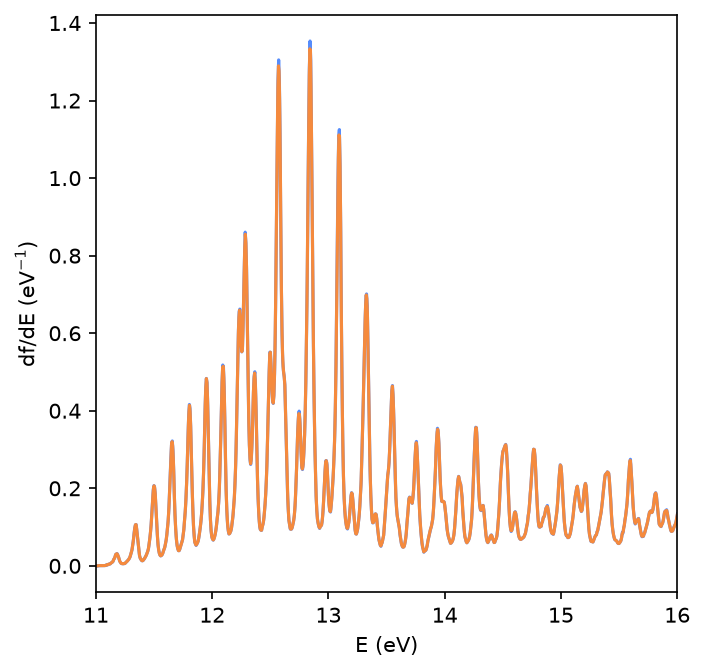

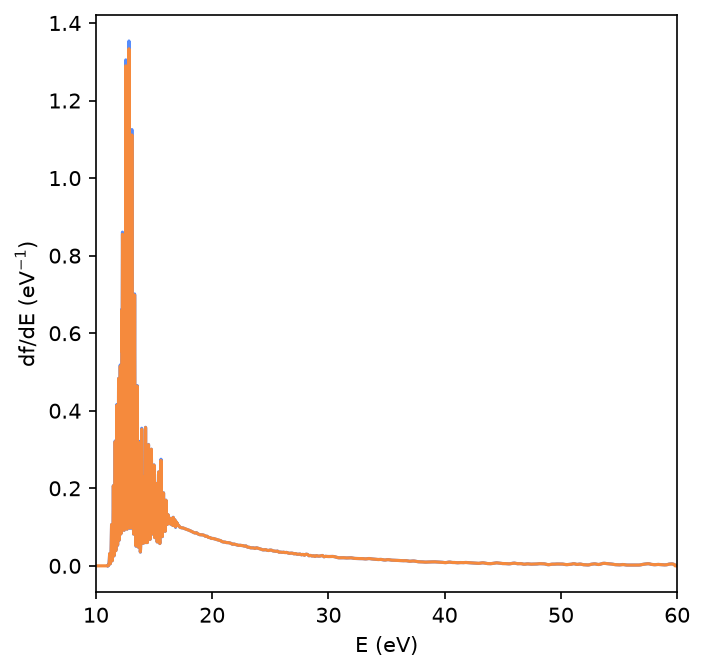

In [12]:

dat=pd.read_csv("./Data/OscStrengthH2.txt", skiprows=57,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)
OscStrH2=interp1d(dat['E'],dat['dfdE'],fill_value=0,bounds_error=False,kind='linear')

plt.figure(figsize=(5,5),dpi=150)
plt.plot(dat.E,dat.dfdE)
Es=np.linspace(10,60,10000)
plt.plot(Es,OscStrH2(Es))
plt.xlim(11,16)
plt.xlabel("E (eV)")
plt.ylabel(r"df/dE (eV$^{-1}$)")
plt.show()

plt.figure(figsize=(5,5),dpi=150)
plt.plot(dat.E,dat.dfdE)
Es=np.linspace(10,60,10000)
plt.plot(Es,OscStrH2(Es))
plt.xlim(10,60)
plt.xlabel("E (eV)")
plt.ylabel(r"df/dE (eV$^{-1}$)")
plt.show()

In [6]:
Ts=np.linspace(1e2,20e3,1000)
sigma_cont=[opticalapprox.sig_oscstrength(T,OscStrH2,constants.mT*2) for T in Ts]


Text(0, 0.5, '$\\sigma (m^2)$')

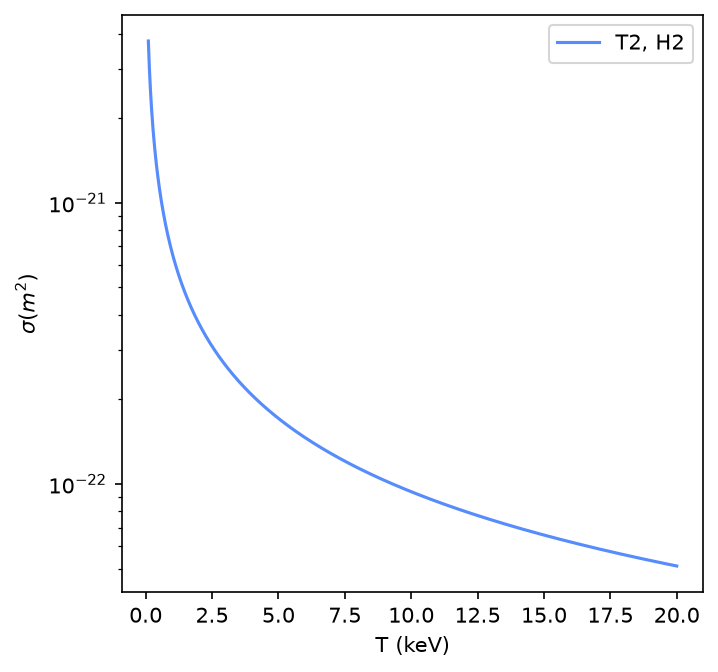

In [17]:
plt.figure(figsize=(5,5),dpi=150)
plt.plot(Ts/1000,sigma_cont,'-',label='T2, H2')
plt.legend(loc='upper right')
plt.semilogy()
plt.xlabel("T (keV)")
plt.ylabel(r"$\sigma (m^2)$")

In [8]:
dTs=[]
dThs=[]
for i in range(0,10000):
    dT,dTh=opticalapprox.SampleKinematics(20e3,OscStrH2,constants.mT*2)
    dTs.append(dT)
    dThs.append(dTh)


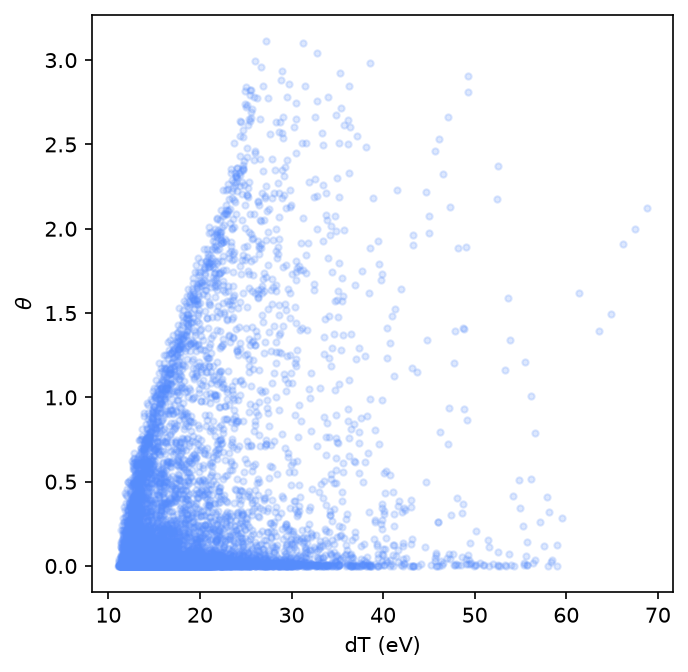

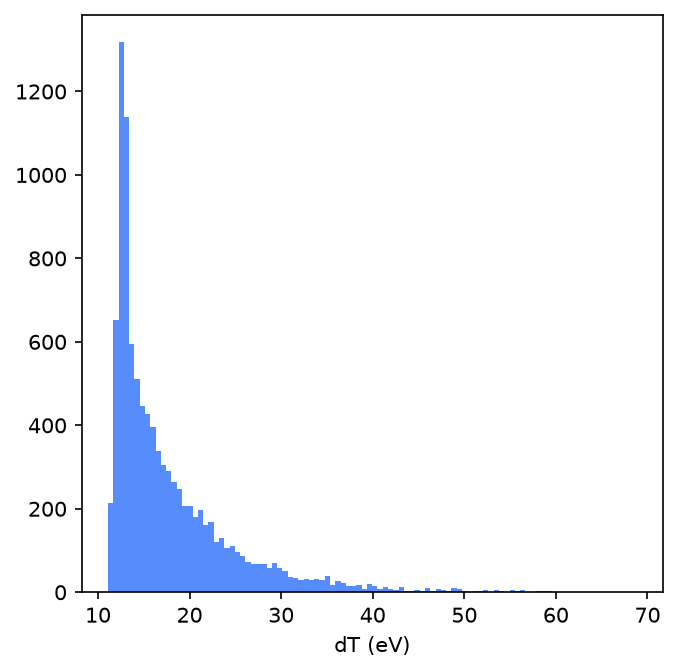

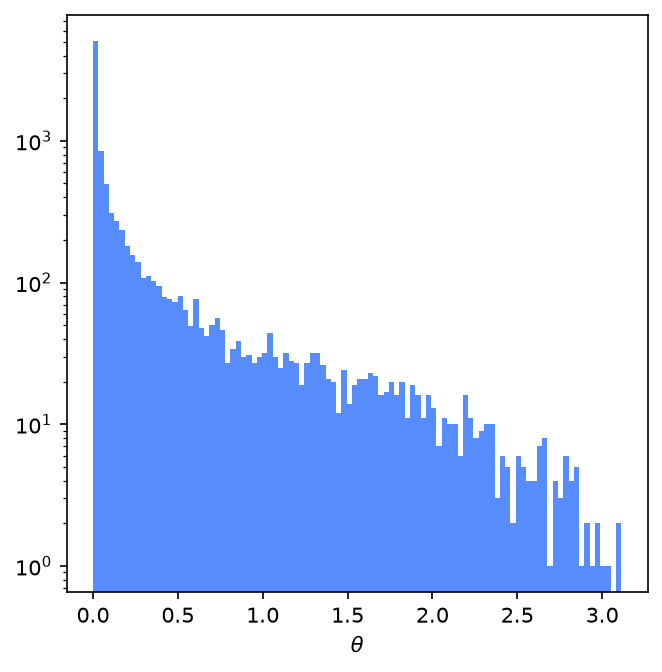

In [9]:
plt.figure(figsize=(5,5),dpi=150)
plt.plot(dTs,dThs,'.',alpha=0.2)
plt.xlabel("dT (eV)" )
plt.ylabel(r"$\theta$")
plt.show()
plt.figure(figsize=(5,5),dpi=150)
plt.hist(dTs,bins=100)
plt.xlabel("dT (eV)")
plt.show()
plt.figure(figsize=(5,5),dpi=150)
plt.hist(dThs,bins=100)
plt.xlabel(r"$\theta$")
plt.semilogy()
plt.show()